# Figure 2 — Passive electrical consequences of OPC morphology

This notebook merges the **GM4 cohort-wide passive simulations** with the morphology table generated for Figure 1. It reproduces all analyses, selects representative cells objectively, performs inferential statistics, and exports figure source data.

**Cohort:** 35 experimentally reconstructed OPCs (P10: 12; P20: 12; P50: 11).

**Baseline passive parameters:** $R_m=20{,}000\,\Omega\cdot\mathrm{cm}^2$, $R_a=150\,\Omega\cdot\mathrm{cm}$, $C_m=1\,\mu\mathrm{F}/\mathrm{cm}^2$, $E_{pas}=-75$ mV, uniform process diameter $0.3\,\mu$m.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
GM4 = Path(r"/mnt/data/fig2_work/4-opc_step4_cohort_passive/opc_step4_passive_results")
MORPH_PATH = Path(r"/mnt/data/figure1_outputs/morphology_master_table.csv")
OUT = Path(r"/mnt/data/figure2_outputs")
OUT.mkdir(exist_ok=True)
AGE_ORDER = ['P10','P20','P50']
plt.rcParams.update({'font.size':9,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':120})


## 1. Load and validate the cohort

In [2]:
passive = pd.read_csv(GM4/'population'/'cell_level_passive_metrics.csv')
morph = pd.read_csv(MORPH_PATH).rename(columns={'age':'age_group'})
merged = passive.merge(morph, on=['cell_id','age_group'], how='left', validate='one_to_one')
print('Passive rows:', len(passive))
print('Merged rows:', len(merged))
print(merged.groupby('age_group').size().reindex(AGE_ORDER))
assert len(merged)==35
assert merged['total_process_length_um'].notna().all()
assert merged['resting_stable'].all()
assert (merged['tau_fit_r2']>0.99).all()
merged.to_csv(OUT/'Figure2_integrated_source_data.csv', index=False)
merged.head()

Passive rows: 35
Merged rows: 35
age_group
P10    12
P20    12
P50    11
dtype: int64


,cell_id,age_group,n_segments,total_cable_length_um,maximum_branch_order,n_terminals,input_resistance_MOhm,tau_ms,tau_fit_r2,maximum_path_distance_um,mean_soma_normalised_attenuation,minimum_soma_normalised_attenuation,resting_stable,matrix_mode,n_transfer_rows,total_process_length_um,n_primary_trees,n_nodes_neurolucida,n_endings_neurolucida,complexity_neurolucida,soma_area_um2,n_reconstructed_segments,n_branch_segments,n_terminal_segments,mean_segment_length_um,median_segment_length_um,max_segment_order,mean_segment_order,mean_node_path_distance_um,max_node_path_distance_um,mean_node_tortuosity,max_radial_extent_um,peak_sholl_intersections,radius_at_peak_sholl_um,sholl_auc_intersections_um
0,NX15_26_P20,P20,737,1785.1,28,407,1113.811709,19.125622,0.999490,82.75,0.969463,0.914064,True,representative,81,1785.3,28,330,408,254468.0,121.0730,737,330,737,2.422117,1.7,28.0,9.287653,26.600606,80.1,1.628777,50.0,43.0,17.5,992.5
1,NX16_1_P20,P20,709,1859.3,20,382,1135.113543,18.812647,0.998959,59.60,0.960387,0.922556,True,representative,81,1858.8,14,327,382,536664.0,35.6174,709,327,709,2.622426,1.8,20.0,9.864598,25.063303,58.8,1.683930,40.0,72.0,20.0,1080.0
2,NX16_2_P20,P20,635,2036.6,21,336,1037.329765,18.548756,0.998548,56.50,0.950297,0.894128,True,representative,81,2037.0,13,299,336,487163.0,55.0373,635,299,635,3.207244,2.3,21.0,8.551181,23.709699,53.4,1.660255,37.5,62.0,15.0,1157.5
3,NX18_15_P50,P50,578,1730.9,20,315,1111.103412,19.495967,0.999813,51.35,0.982989,0.958671,True,representative,81,1730.7,21,263,315,199686.0,154.6860,578,263,578,2.994637,2.2,20.0,7.062284,17.340304,48.1,1.533769,47.5,53.0,22.5,1060.0
4,NX22_1_P10,P10,384,799.6,16,209,2334.253573,19.721745,0.999942,52.50,0.989728,0.968807,True,representative,81,799.1,15,175,209,82521.3,90.4409,384,175,384,2.082292,1.5,16.0,6.757812,14.372571,51.9,1.615286,27.5,35.0,12.5,452.5


## 2. Descriptive and inferential statistics

Age-group comparisons use Kruskal–Wallis tests followed by pairwise Mann–Whitney tests with Holm correction. Spearman correlations quantify morphology–electrical relationships. Effect sizes for pairwise comparisons are rank-biserial correlations.

In [3]:
metrics = {
 'input_resistance_MOhm':'Input resistance (MΩ)',
 'tau_ms':'Membrane time constant (ms)',
 'minimum_soma_normalised_attenuation':'Minimum soma-normalised attenuation',
 'mean_soma_normalised_attenuation':'Mean soma-normalised attenuation'
}
rows=[]; pair_rows=[]
for col,label in metrics.items():
    groups=[merged.loc[merged.age_group==a,col].dropna() for a in AGE_ORDER]
    H,p=stats.kruskal(*groups)
    rows.append({'metric':col,'label':label,'test':'Kruskal-Wallis','statistic':H,'p_value':p})
    raw=[]
    for i,a in enumerate(AGE_ORDER):
        for b in AGE_ORDER[i+1:]:
            x=merged.loc[merged.age_group==a,col].dropna(); y=merged.loc[merged.age_group==b,col].dropna()
            U,pairp=stats.mannwhitneyu(x,y,alternative='two-sided')
            rbc=1-2*U/(len(x)*len(y))
            raw.append([a,b,U,pairp,rbc])
    adj=multipletests([r[3] for r in raw],method='holm')[1]
    for r,pa in zip(raw,adj):
        pair_rows.append({'metric':col,'group_1':r[0],'group_2':r[1],'U':r[2],'p_raw':r[3],'p_holm':pa,'rank_biserial':r[4]})
overall=pd.DataFrame(rows); pairwise=pd.DataFrame(pair_rows)
desc=merged.groupby('age_group')[list(metrics)].agg(['count','mean','std','median','min','max']).reindex(AGE_ORDER)
overall.to_csv(OUT/'Figure2_overall_tests.csv',index=False)
pairwise.to_csv(OUT/'Figure2_pairwise_tests.csv',index=False)
desc.to_csv(OUT/'Figure2_descriptive_statistics.csv')
display(overall)
display(pairwise.sort_values(['metric','p_holm']))

,metric,label,test,statistic,p_value
0,input_resistance_MOhm,Input resistance (MΩ),Kruskal-Wallis,10.994733,0.004098
1,tau_ms,Membrane time constant (ms),Kruskal-Wallis,8.534993,0.014017
2,minimum_soma_normalised_attenuation,Minimum soma-normalised attenuation,Kruskal-Wallis,8.661400,0.013158
3,mean_soma_normalised_attenuation,Mean soma-normalised attenuation,Kruskal-Wallis,9.145599,0.010329


,metric,group_1,group_2,U,p_raw,p_holm,rank_biserial
0,input_resistance_MOhm,P10,P20,121.0,0.005108,0.015324,-0.680556
1,input_resistance_MOhm,P10,P50,111.0,0.006167,0.015324,-0.681818
2,input_resistance_MOhm,P20,P50,52.0,0.406048,0.406048,0.212121
9,mean_soma_normalised_attenuation,P10,P20,121.0,0.005108,0.015324,-0.680556
10,mean_soma_normalised_attenuation,P10,P50,104.0,0.021001,0.042002,-0.575758
11,mean_soma_normalised_attenuation,P20,P50,68.0,0.926445,0.926445,-0.030303
6,minimum_soma_normalised_attenuation,P10,P20,121.0,0.005108,0.015324,-0.680556
7,minimum_soma_normalised_attenuation,P10,P50,101.0,0.033726,0.067453,-0.530303
8,minimum_soma_normalised_attenuation,P20,P50,62.0,0.829448,0.829448,0.060606
3,tau_ms,P10,P20,117.0,0.010193,0.030579,-0.625000


## 3. Morphology–electrical relationships

In [4]:
predictors=['total_process_length_um','max_node_path_distance_um','n_terminal_segments','n_branch_segments']
corr=[]
for x in predictors:
    rho,p=stats.spearmanr(merged[x],merged['input_resistance_MOhm'],nan_policy='omit')
    corr.append({'outcome':'input_resistance_MOhm','predictor':x,'spearman_rho':rho,'p_value':p})
corr=pd.DataFrame(corr)
corr['p_holm']=multipletests(corr.p_value,method='holm')[1]
corr.to_csv(OUT/'Figure2_morphology_correlations.csv',index=False)
display(corr.sort_values('p_holm'))

# Exploratory standardised multivariable OLS; descriptors chosen a priori and kept few for n=35.
Xcols=['total_process_length_um','max_node_path_distance_um','n_terminal_segments']
X=pd.DataFrame(StandardScaler().fit_transform(merged[Xcols]),columns=Xcols,index=merged.index)
X=sm.add_constant(X)
model=sm.OLS(merged['input_resistance_MOhm'],X).fit(cov_type='HC3')
coef=pd.DataFrame({'term':model.params.index,'coefficient':model.params.values,'SE_HC3':model.bse.values,'p_value':model.pvalues.values})
coef.to_csv(OUT/'Figure2_exploratory_regression.csv',index=False)
print(model.summary())

,outcome,predictor,spearman_rho,p_value,p_holm
0,input_resistance_MOhm,total_process_length_um,-0.990756,3.261725e-30,1.304690e-29
2,input_resistance_MOhm,n_terminal_segments,-0.833613,5.083489e-10,1.525047e-09
3,input_resistance_MOhm,n_branch_segments,-0.818125,1.952981e-09,3.905961e-09
1,input_resistance_MOhm,max_node_path_distance_um,-0.490579,2.771678e-03,2.771678e-03


                              OLS Regression Results                             
Dep. Variable:     input_resistance_MOhm   R-squared:                       0.882
Model:                               OLS   Adj. R-squared:                  0.870
Method:                    Least Squares   F-statistic:                     24.70
Date:                   Mon, 27 Jul 2026   Prob (F-statistic):           2.33e-08
Time:                           16:10:00   Log-Likelihood:                -221.05
No. Observations:                     35   AIC:                             450.1
Df Residuals:                         31   BIC:                             456.3
Df Model:                              3                                         
Covariance Type:                     HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------

## 4. Representative cells and voltage traces

For visual continuity with Figure 1, the representative cells are those selected there as closest to the multivariate age-group median: NX64_2_P10, NX16_1_P20, and NX90_20_P50.

In [5]:
representatives={'P10':'NX64_2_P10','P20':'NX16_1_P20','P50':'NX90_20_P50'}
trace_frames=[]
for age,cid in representatives.items():
    f=GM4/'cells'/cid/f'{cid}_soma_trace.csv'
    tr=pd.read_csv(f)
    tr['cell_id']=cid; tr['age_group']=age
    tr['delta_V_mV']=tr['soma_mV']-tr['soma_mV'].iloc[0]
    trace_frames.append(tr)
traces=pd.concat(trace_frames,ignore_index=True)
traces.to_csv(OUT/'Figure2_representative_traces.csv',index=False)
merged.loc[merged.cell_id.isin(representatives.values()),['cell_id','age_group','input_resistance_MOhm','tau_ms','minimum_soma_normalised_attenuation']]

,cell_id,age_group,input_resistance_MOhm,tau_ms,minimum_soma_normalised_attenuation
1,NX16_1_P20,P20,1135.113543,18.812647,0.922556
18,NX64_2_P10,P10,1542.823866,18.791592,0.906354
31,NX90_20_P50,P50,1024.448036,18.712194,0.899810


## 5. Draft Figure 2

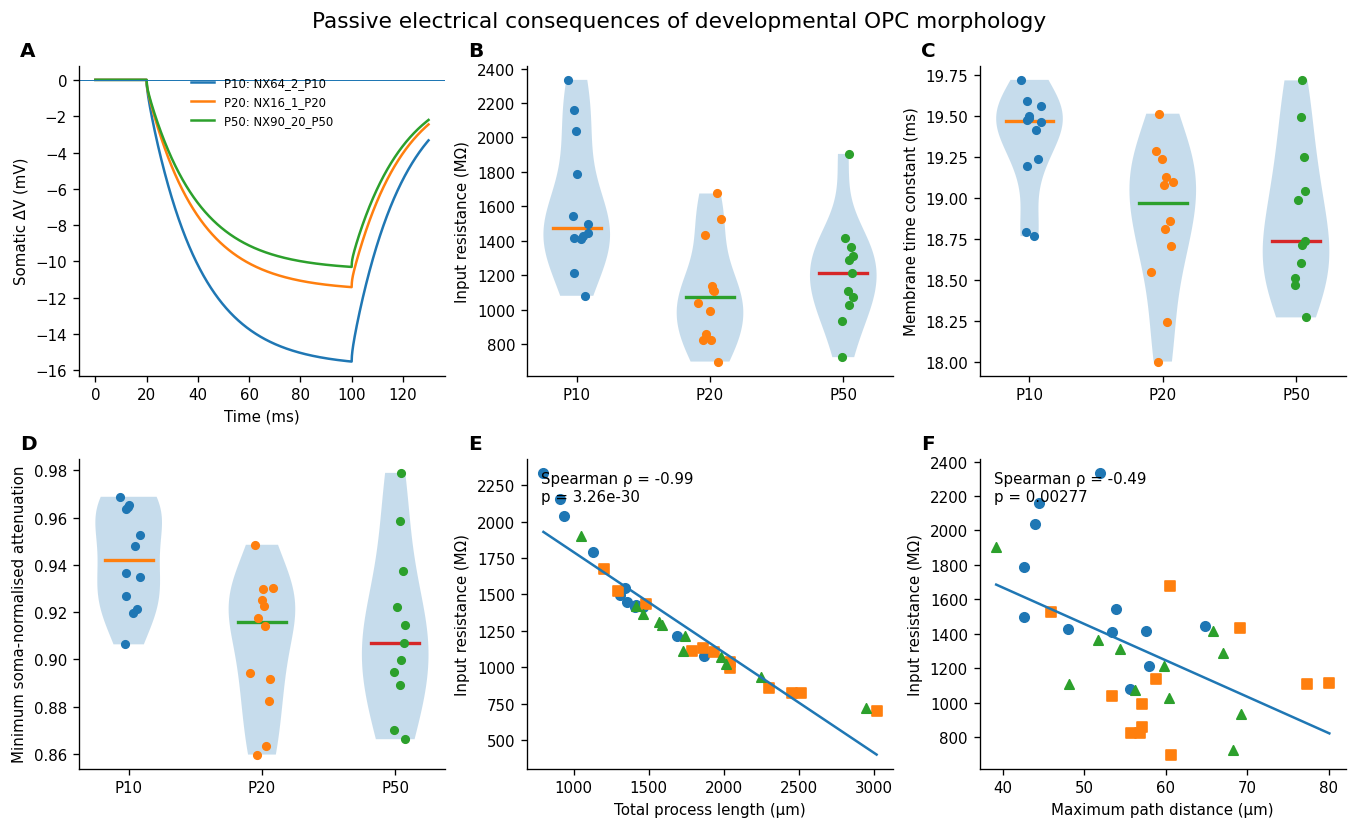

In [6]:
def grouped_points(ax,col,ylabel):
    vals=[merged.loc[merged.age_group==a,col].dropna().values for a in AGE_ORDER]
    parts=ax.violinplot(vals,positions=np.arange(3),showmeans=False,showmedians=False,showextrema=False)
    for pc in parts['bodies']: pc.set_alpha(0.25)
    rng=np.random.default_rng(20260727)
    for i,v in enumerate(vals):
        ax.scatter(np.full(len(v),i)+rng.uniform(-.09,.09,len(v)),v,s=20,zorder=3)
        ax.plot([i-.18,i+.18],[np.median(v)]*2,lw=2)
    ax.set_xticks(range(3),AGE_ORDER); ax.set_ylabel(ylabel)

def scatter_fit(ax,x,y,xlabel,ylabel):
    for age,marker in zip(AGE_ORDER,['o','s','^']):
        d=merged[merged.age_group==age]
        ax.scatter(d[x],d[y],label=age,marker=marker,s=32)
    ok=merged[[x,y]].dropna(); slope,intercept,r,p,se=stats.linregress(ok[x],ok[y])
    xx=np.linspace(ok[x].min(),ok[x].max(),100)
    ax.plot(xx,intercept+slope*xx,lw=1.5)
    rho,ps=stats.spearmanr(ok[x],ok[y])
    ax.text(.04,.96,f'Spearman ρ = {rho:.2f}\np = {ps:.3g}',transform=ax.transAxes,va='top')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)

fig,axs=plt.subplots(2,3,figsize=(11.2,6.8),constrained_layout=True)
# A
ax=axs[0,0]
for age in AGE_ORDER:
    d=traces[traces.age_group==age]
    ax.plot(d.time_ms,d.delta_V_mV,label=f"{age}: {representatives[age]}")
ax.axhline(0,lw=.6); ax.set_xlabel('Time (ms)'); ax.set_ylabel('Somatic ΔV (mV)'); ax.legend(frameon=False,fontsize=7)
# B-D
grouped_points(axs[0,1],'input_resistance_MOhm','Input resistance (MΩ)')
grouped_points(axs[0,2],'tau_ms','Membrane time constant (ms)')
grouped_points(axs[1,0],'minimum_soma_normalised_attenuation','Minimum soma-normalised attenuation')
# E-F
scatter_fit(axs[1,1],'total_process_length_um','input_resistance_MOhm','Total process length (µm)','Input resistance (MΩ)')
scatter_fit(axs[1,2],'max_node_path_distance_um','input_resistance_MOhm','Maximum path distance (µm)','Input resistance (MΩ)')
for label,ax in zip('ABCDEF',axs.flat): ax.text(-.16,1.08,label,transform=ax.transAxes,fontweight='bold',fontsize=12,va='top')
fig.suptitle('Passive electrical consequences of developmental OPC morphology',fontsize=13)
for ext in ['pdf','png','svg']:
    fig.savefig(OUT/f'Figure2_passive_electrical_properties.{ext}',dpi=400 if ext=='png' else None,bbox_inches='tight')
plt.show()

## 6. Analysis summary

In [7]:
print('Cohort:', merged.groupby('age_group').size().reindex(AGE_ORDER).to_dict())
print()
print('Overall tests:')
display(overall)
print()
print('Representative cells:', representatives)
print()
print('All source data and statistics exported to:', OUT)


Cohort: {'P10': 12, 'P20': 12, 'P50': 11}

Overall tests:


,metric,label,test,statistic,p_value
0,input_resistance_MOhm,Input resistance (MΩ),Kruskal-Wallis,10.994733,0.004098
1,tau_ms,Membrane time constant (ms),Kruskal-Wallis,8.534993,0.014017
2,minimum_soma_normalised_attenuation,Minimum soma-normalised attenuation,Kruskal-Wallis,8.661400,0.013158
3,mean_soma_normalised_attenuation,Mean soma-normalised attenuation,Kruskal-Wallis,9.145599,0.010329



Representative cells: {'P10': 'NX64_2_P10', 'P20': 'NX16_1_P20', 'P50': 'NX90_20_P50'}

All source data and statistics exported to: /mnt/data/figure2_outputs
